# Import bibliotek i definicje funckji z poprzednich laboratoriów

In [169]:
import numpy as np
import cv2
import matplotlib.pyplot as plt


class Point:
    def __init__(self, x, y, z):
        self.coords = np.array([x, y, z])

    def __getitem__(self, index):
        return self.coords[index]


class Triangle:
    def __init__(self, p1: Point, p2: Point, p3: Point):
        self.p1 = p1
        self.p2 = p2
        self.p3 = p3
        self.epsilon = 1


class Light:
    def __init__(self, position: Point, intensity: float):
        self.position = position
        self.intensity = intensity


def mat2pix(m, n, dx, dy, x, y):
    """
    m, n - size of the image in pixels
    dx, dy - size of the image in math coordinates
    x, y - math coordinates of the point
    """
    transformMatrix = np.array([[1 / dx, 0, 0.5 * m], [0, -1 / dy, 0.5 * n], [0, 0, 1]])

    pixelCoords = np.dot(transformMatrix, np.array([x, y, 1]))
    # KONWERSJA DO INT jest ważna dla funkcji cv2.fillPoly
    # poza tym tak jest bardziej logicznie, ponieważ współrzędne pikseli powinny być liczbami całkowitymi
    px = int(round(pixelCoords[0] / pixelCoords[2]))
    py = int(round(pixelCoords[1] / pixelCoords[2]))
    return px, py


def pix2mat(m, n, dx, dy, u, v):
    transformMatrix = np.array(
        [[dx, 0, -0.5 * m * dx], [0, -dy, 0.5 * n * dy], [0, 0, 1]]
    )

    mathCords = np.dot(transformMatrix, np.array([u, v, 1]))
    return (mathCords[0] / mathCords[2]), (mathCords[1] / mathCords[2])


def distance2plane(point, A, b, c, d, DirX, DirY, DirZ):
    """
    Oblicza odległość punktu 3D od płaszczyzny oraz wyznacza punkt na płaszczyźnie,
    który jest rzutem prostopadłym danego punktu.

    Argumenty:
    point : array-like o długości 3
        Punkt 3D w postaci [x, y, z].
    A, b, c, d : float
        Współczynniki równania płaszczyzny:
        A*x + b*y + c*z + d = 0.

    Zwraca:
    tuple[float, np.ndarray]
        - float: Nieujemna odległość punktu od płaszczyzny.
        - np.ndarray: Punkt 3D na płaszczyźnie (rzut prostopadły danego punktu).
    """

    # jeśli DirX, DirY, DirZ są użyte to są one wektorem według którego rzutujemy punkt na płaszczyzne
    if DirX is not None and DirY is not None and DirZ is not None:
        # normalizacja wektora kierunkowego
        dir_vector = np.array([DirX, DirY, DirZ], dtype=float)
        dir_vector /= np.linalg.norm(dir_vector)

        # obliczenie odległości punktu od płaszczyzny wzdłuż wektora kierunkowego
        numerator = A * point[0] + b * point[1] + c * point[2] + d
        denominator = A * dir_vector[0] + b * dir_vector[1] + c * dir_vector[2]

        if np.isclose(denominator, 0.0):
            raise ValueError(
                "Wektor kierunkowy jest równoległy do płaszczyzny, rzutowanie jest niemożliwe."
            )

        t = -numerator / denominator

        # współrzędne punktu na płaszczyźnie
        plane_point = np.array([point[0], point[1], point[2]]) + t * dir_vector

        return float(t), plane_point

    point = np.asarray(point, dtype=float)
    x, y, z = point

    mianownik = A**2 + b**2 + c**2

    if np.isclose(mianownik, 0.0):
        raise ValueError(
            "Nieprawidłowa płaszczyzna: A, b, c nie mogą być jednocześnie zerowe."
        )

    licznik = A * x + b * y + c * z + d

    # Parametr t dla punktu na płaszczyźnie (rzut prostopadły)
    t = -licznik / mianownik

    # Współrzędne punktu na płaszczyźnie
    x_plane = x + t * A
    y_plane = y + t * b
    z_plane = z + t * c
    plane_point = np.array([x_plane, y_plane, z_plane])

    # Odległość
    distance = np.abs(licznik) / np.sqrt(mianownik)

    return float(distance), plane_point


def plane(Triangle):
    """
    Wyznacza równanie płaszczyzny przechodzącej przez trzy punkty 3D.

    Argumenty:
    Triangle : Triangle
        Trójkąt, dla którego wyznaczamy równanie płaszczyzny.

    Zwraca:
    tuple[float, float, float, float]
        Współczynniki (A, b, c, d) równania płaszczyzny:
        A*x + b*y + c*z + d = 0.

    """
    p1 = np.asarray(Triangle.p1.coords, dtype=float)
    p2 = np.asarray(Triangle.p2.coords, dtype=float)
    p3 = np.asarray(Triangle.p3.coords, dtype=float)

    v1 = p2 - p1
    v2 = p3 - p1
    normal = np.cross(v1, v2)

    if np.allclose(normal, 0.0):
        raise ValueError("Punkty są współliniowe - nie wyznaczają płaszczyzny.")

    A, b, c = normal
    d = -np.dot(normal, p1)
    return float(A), float(b), float(c), float(d)

# definicja funkcji modeli oświetlenia

In [170]:
def DrawTriangleWithLambert(
    Image, Triangle, Lights, ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, AMBIENT_LIGHT
):

    imgCopy = Image.copy()
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]

    # aby skrócić kod, korzystam z funkcji fillPoly z biblioteki cv2 zamiast z ręcznie pisanych funkcji
    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))

    # plt.imshow(imgCopy)
    # plt.axis("off")
    # plt.title(
    #     f"Maska trójkąta: {Triangle.p1.coords}, {Triangle.p2.coords}, {Triangle.p3.coords}"
    # )
    # plt.show()
    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )

    # znormalizu wektor normalny
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)

    # WSPÓŁCZYNNIKI PŁASZCZYZNY
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # pętla rysująca obraz TYLKO danego trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            final_intensity = AMBIENT_LIGHT
            # pomijamy piksele nie należące do trójkąta
            if not np.all(imgCopy[y, x] == 255):
                continue

            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            _, plane_point = distance2plane(
                Point(X_world, Y_world, 0), A, B, C, D, 0, 0, 1
            )

            for light in Lights:
                light_vector = light.position.coords - plane_point
                # podobno najlepsza metoda na obliczenie długości wektora w pythonie (Google)
                light_distance = np.linalg.norm(light_vector)
                light_vector_normalized = light_vector / light_distance

                angle_cos = np.dot(triangle_normal, light_vector_normalized)
                final_intensity += (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * max(angle_cos, 0)
                )
            final_intensity = max(0, min(255, int(final_intensity)))
            imgCopy[y, x] = (final_intensity, final_intensity, final_intensity)

    return imgCopy


def DrawTriangleWithPhong(
    Image,
    Triangle,
    Lights,
    ROZDZIELCZOSC_X,
    ROZDZIELCZOSC_Y,
    DX,
    DY,
    AMBIENT_LIGHT,
    eye_position,
):

    imgCopy = np.zeros_like(Image)
    TrianglePixelCoords = [
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p1[0], Triangle.p1[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p2[0], Triangle.p2[1]
        ),
        mat2pix(
            ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, Triangle.p3[0], Triangle.p3[1]
        ),
    ]

    imgCopy = cv2.fillPoly(imgCopy, [np.array(TrianglePixelCoords)], (255, 255, 255))
    triangle_normal = np.cross(
        Triangle.p2.coords - Triangle.p1.coords, Triangle.p3.coords - Triangle.p1.coords
    )

    # znormalizu wektor normalny
    triangle_normal = triangle_normal / np.linalg.norm(triangle_normal)

    # WSPÓŁCZYNNIKI PŁASZCZYZNY
    A, B, C = triangle_normal
    D = -np.dot(triangle_normal, Triangle.p1.coords)

    # pętla rysująca obraz TYLKO danego trójkąta
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            final_intensity = AMBIENT_LIGHT
            # pomijamy piksele nie należące do trójkąta
            if not imgCopy[y, x][0] == 255:
                continue

            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            _, plane_point = distance2plane(
                Point(X_world, Y_world, 0), A, B, C, D, 0, 0, 1
            )

            for light in Lights:
                light_vector = light.position.coords - plane_point
                # podobno najlepsza metoda na obliczenie długości wektora w pythonie (Google)
                light_distance = np.linalg.norm(light_vector)
                light_vector_normalized = light_vector / light_distance

                angle_cos = np.dot(triangle_normal, light_vector_normalized)

                labmert_diffuse = (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * max(angle_cos, 0)
                )

                reflection_vector = (
                    2 * angle_cos * triangle_normal - light_vector_normalized
                )

                eye_vector = eye_position.coords - plane_point
                eye_vector_normalized = eye_vector / np.linalg.norm(eye_vector)
                specular_dot = np.dot(reflection_vector, eye_vector_normalized)
                specular_contribution = (
                    light.intensity
                    / (1 + 0.001 * light_distance**2)
                    * (max(specular_dot, 0) ** 15)
                )

                final_intensity += labmert_diffuse + specular_contribution

            final_intensity = max(0, min(255, int(final_intensity)))
            imgCopy[y, x] = (final_intensity, final_intensity, final_intensity)

    return imgCopy

# Zadanie 1 


In [171]:
def rzucanieCienia(
    Image,
    Triangle,
    Other_Triangles,
    Lights,
    ROZDZIELCZOSC_X,
    ROZDZIELCZOSC_Y,
    DX,
    DY,
    AMBIENT_LIGHT,
):
    imgCopy = Image.copy()
    A, B, C, D = plane(Triangle)
    triangle_normal = np.array([A, B, C])
    triangle_normal /= np.linalg.norm(triangle_normal)
    for y in range(imgCopy.shape[0]):
        for x in range(imgCopy.shape[1]):
            # pomijamy piksele nie należące do trójkąta
            if any(imgCopy[y, x] == 0):
                continue

            X_world, Y_world = pix2mat(ROZDZIELCZOSC_X, ROZDZIELCZOSC_Y, DX, DY, x, y)
            _, plane_point = distance2plane(
                Point(X_world, Y_world, 0), A, B, C, D, 0, 0, 1
            )
            light_vector = plane_point - Lights[0].position.coords
            light_distance = np.linalg.norm(light_vector)
            light_vector /= light_distance

            for other_triangle in Other_Triangles:
                # nie zacieniamy trójkąta przez samego siebie
                if other_triangle == Triangle:
                    continue
                A2, B2, C2, D2 = plane(other_triangle)
                distance, _ = distance2plane(
                    Lights[0].position.coords,
                    A2,
                    B2,
                    C2,
                    D2,
                    light_vector[0],
                    light_vector[1],
                    light_vector[2],
                )
                # przeciecie musi być na odcinku od światła do punktu
                if 0 < distance < light_distance:
                    hit_point = Lights[0].position.coords + distance * light_vector
                    p1 = other_triangle.p1.coords
                    p2 = other_triangle.p2.coords
                    p3 = other_triangle.p3.coords
                    n = np.cross(p2 - p1, p3 - p1)
                    # pomijamy zdegradowany trójkąt
                    if np.allclose(n, 0.0):
                        continue
                    d1 = np.dot(n, np.cross(p2 - p1, hit_point - p1))
                    d2 = np.dot(n, np.cross(p3 - p2, hit_point - p2))
                    d3 = np.dot(n, np.cross(p1 - p3, hit_point - p3))
                    # punkt trafienia musi leżeć wewnątrz trójkąta
                    if (d1 >= 0 and d2 >= 0 and d3 >= 0) or (
                        d1 <= 0 and d2 <= 0 and d3 <= 0
                    ):
                        imgCopy[y, x] = AMBIENT_LIGHT
                        break
    return imgCopy


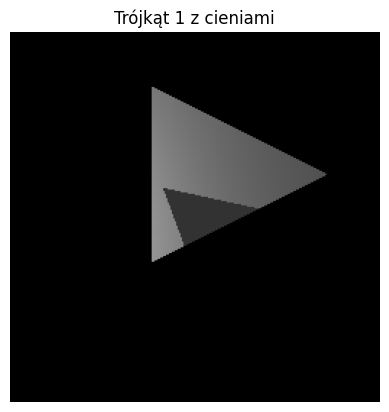

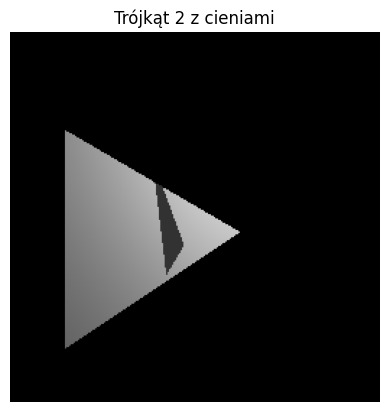

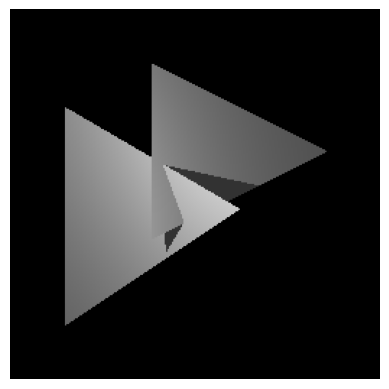

In [172]:
Triangles = [
    Triangle(Point(-3, -3, 4), Point(-3, 9, 6), Point(9, 3, 16)),
    Triangle(Point(-9, -9, 18), Point(-9, 6, 10), Point(3, -1, 2)),
]

AMBIENT_LIGHT = 50
resX, resY = 256, 256
DX, DY = 0.1, 0.1
Lights = [Light(Point(-6, 0, -10), 205)]

image = np.zeros((resY, resX, 3), dtype=np.uint8)
TriangleImages = []
# 1. Rysujemy osobne obrazy oświetlonych trójkątów
for triangle in Triangles:
    TriangleImages.append(
        DrawTriangleWithLambert(
            image, triangle, Lights, resX, resY, DX, DY, AMBIENT_LIGHT
        )
    )

# 2. Rysujemy cienie rzucane przez trójkąty
for idx, triangle in enumerate(Triangles):
    TriangleImages[idx] = rzucanieCienia(
        TriangleImages[idx],
        triangle,
        Triangles,
        Lights,
        resX,
        resY,
        DX,
        DY,
        AMBIENT_LIGHT,
    )
    plt.imshow(TriangleImages[idx])
    plt.axis("off")
    plt.title(f"Trójkąt {idx + 1} z cieniami")
    plt.show()


# 3. finalny z-buffer
for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        minDistance = float("inf")
        for idx, triangle in enumerate(Triangles):
            if TriangleImages[idx][y, x][0] == 0:
                continue
            X_world, Y_world = pix2mat(resX, resY, DX, DY, x, y)
            A, B, C, D = plane(triangle)

            distance, plane_point = distance2plane(
                Point(X_world, Y_world, 0), A, B, C, D, 0, 0, 1
            )
            if distance < minDistance:
                minDistance = distance
                image[y, x] = TriangleImages[idx][y, x]


plt.imshow(image)
plt.axis("off")
plt.show()


# Zadanie 1 b. - światło w punkcie [0,0,-10]

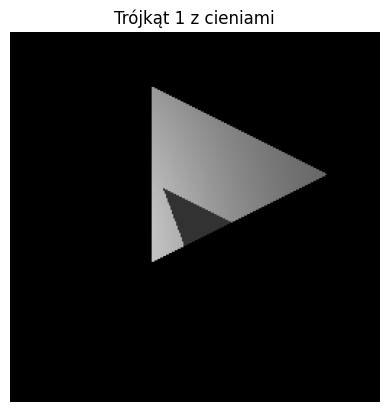

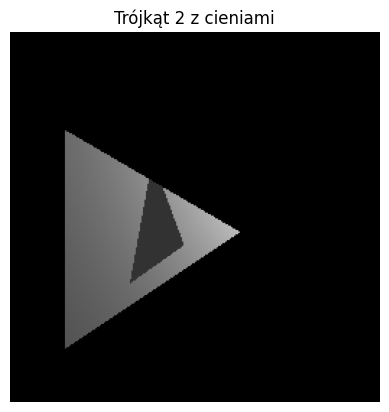

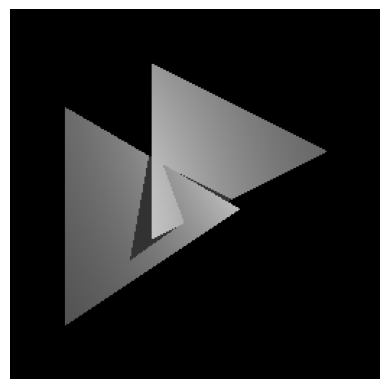

In [173]:
Triangles = [
    Triangle(Point(-3, -3, 4), Point(-3, 9, 6), Point(9, 3, 16)),
    Triangle(Point(-9, -9, 18), Point(-9, 6, 10), Point(3, -1, 2)),
]

AMBIENT_LIGHT = 50
resX, resY = 256, 256
DX, DY = 0.1, 0.1
Lights = [Light(Point(0, 0, -10), 205)]

image = np.zeros((resY, resX, 3), dtype=np.uint8)
TriangleImages = []
# 1. Rysujemy osobne obrazy oświetlonych trójkątów
for triangle in Triangles:
    TriangleImages.append(
        DrawTriangleWithLambert(
            image, triangle, Lights, resX, resY, DX, DY, AMBIENT_LIGHT
        )
    )
# 2. Rysujemy cienie rzucane przez trójkąty

for idx, triangle in enumerate(Triangles):
    TriangleImages[idx] = rzucanieCienia(
        TriangleImages[idx],
        triangle,
        Triangles,
        Lights,
        resX,
        resY,
        DX,
        DY,
        AMBIENT_LIGHT,
    )
    plt.imshow(TriangleImages[idx])
    plt.axis("off")
    plt.title(f"Trójkąt {idx + 1} z cieniami")
    plt.show()


# 3. finalny z-buffer
for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        minDistance = float("inf")
        for idx, triangle in enumerate(Triangles):
            if TriangleImages[idx][y, x][0] == 0:
                continue
            X_world, Y_world = pix2mat(resX, resY, DX, DY, x, y)
            A, B, C, D = plane(triangle)

            distance, plane_point = distance2plane(
                Point(X_world, Y_world, 0), A, B, C, D, 0, 0, 1
            )
            if distance < minDistance:
                minDistance = distance
                image[y, x] = TriangleImages[idx][y, x]


plt.imshow(image)
plt.axis("off")
plt.show()

# Zadanie 2 - ta sama scena z modelem oświetlenia Phonga

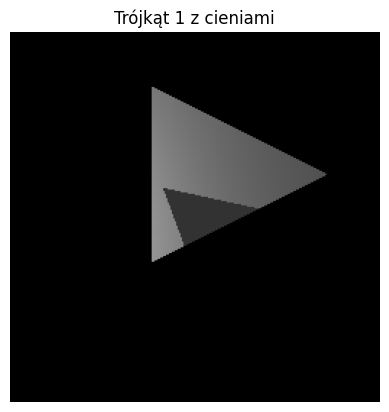

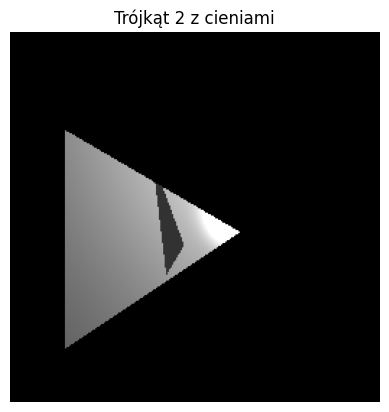

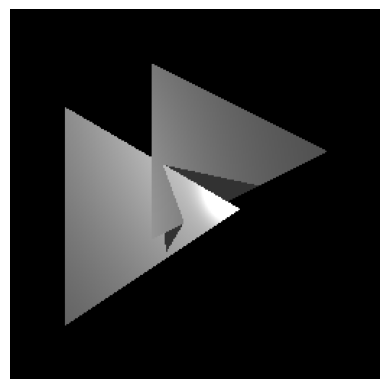

In [174]:
Triangles = [
    Triangle(Point(-3, -3, 4), Point(-3, 9, 6), Point(9, 3, 16)),
    Triangle(Point(-9, -9, 18), Point(-9, 6, 10), Point(3, -1, 2)),
]

AMBIENT_LIGHT = 50
EYE_POSITION = Point(-3, -5, 0)
resX, resY = 256, 256
DX, DY = 0.1, 0.1
Lights = [Light(Point(-6, 0, -10), 205)]

image = np.zeros((resY, resX, 3), dtype=np.uint8)
TriangleImages = []
# 1. Rysujemy osobne obrazy oświetlonych trójkątów
for triangle in Triangles:
    TriangleImages.append(
        DrawTriangleWithPhong(
            image, triangle, Lights, resX, resY, DX, DY, AMBIENT_LIGHT, EYE_POSITION
        )
    )
# 2. Rysujemy cienie rzucane przez trójkąty

for idx, triangle in enumerate(Triangles):
    TriangleImages[idx] = rzucanieCienia(
        TriangleImages[idx],
        triangle,
        Triangles,
        Lights,
        resX,
        resY,
        DX,
        DY,
        AMBIENT_LIGHT,
    )
    plt.imshow(TriangleImages[idx])
    plt.axis("off")
    plt.title(f"Trójkąt {idx + 1} z cieniami")
    plt.show()


# 3. finalny z-buffer
for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        minDistance = float("inf")
        for idx, triangle in enumerate(Triangles):
            if TriangleImages[idx][y, x][0] == 0:
                continue
            X_world, Y_world = pix2mat(resX, resY, DX, DY, x, y)
            A, B, C, D = plane(triangle)

            distance, plane_point = distance2plane(
                Point(X_world, Y_world, 0), A, B, C, D, 0, 0, 1
            )
            if distance < minDistance:
                minDistance = distance
                image[y, x] = TriangleImages[idx][y, x]


plt.imshow(image)
plt.axis("off")
plt.show()

# Zadanie 2b - swiatlo w punkcie [0,0,-10], oko w punkcie [5,0,0]

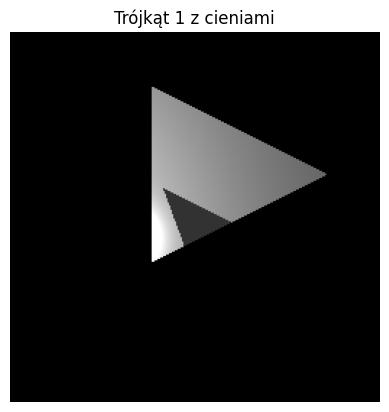

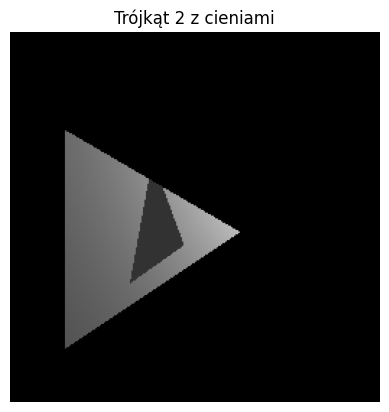

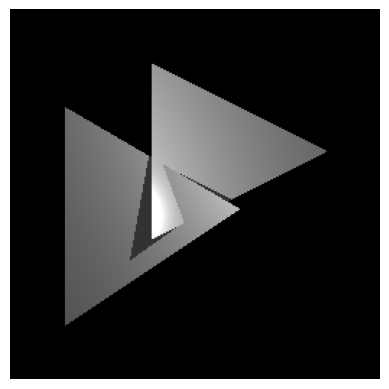

In [175]:
Triangles = [
    Triangle(Point(-3, -3, 4), Point(-3, 9, 6), Point(9, 3, 16)),
    Triangle(Point(-9, -9, 18), Point(-9, 6, 10), Point(3, -1, 2)),
]

AMBIENT_LIGHT = 50
EYE_POSITION = Point(5, 0, 0)
resX, resY = 256, 256
DX, DY = 0.1, 0.1
Lights = [Light(Point(0, 0, -10), 205)]

image = np.zeros((resY, resX, 3), dtype=np.uint8)
TriangleImages = []
# 1. Rysujemy osobne obrazy oświetlonych trójkątów
for triangle in Triangles:
    TriangleImages.append(
        DrawTriangleWithPhong(
            image, triangle, Lights, resX, resY, DX, DY, AMBIENT_LIGHT, EYE_POSITION
        )
    )
# 2. Rysujemy cienie rzucane przez trójkąty

for idx, triangle in enumerate(Triangles):
    TriangleImages[idx] = rzucanieCienia(
        TriangleImages[idx],
        triangle,
        Triangles,
        Lights,
        resX,
        resY,
        DX,
        DY,
        AMBIENT_LIGHT,
    )
    plt.imshow(TriangleImages[idx])
    plt.axis("off")
    plt.title(f"Trójkąt {idx + 1} z cieniami")
    plt.show()


# 3. finalny z-buffer
for y in range(image.shape[0]):
    for x in range(image.shape[1]):
        minDistance = float("inf")
        for idx, triangle in enumerate(Triangles):
            if TriangleImages[idx][y, x][0] == 0:
                continue
            X_world, Y_world = pix2mat(resX, resY, DX, DY, x, y)
            A, B, C, D = plane(triangle)

            distance, plane_point = distance2plane(
                Point(X_world, Y_world, 0), A, B, C, D, 0, 0, 1
            )
            if distance < minDistance:
                minDistance = distance
                image[y, x] = TriangleImages[idx][y, x]


plt.imshow(image)
plt.axis("off")
plt.show()